In [ ]:
# ============================================================
# NewsBot Intelligence System
# ITAI 2373 Midterm Project
# Student: David Massiala
# ============================================================

print("NewsBot Intelligence System")
print("Project Started Successfully!")

NewsBot Intelligence System
Project Started Successfully!


In [ ]:
# Install required libraries

!pip install -q pandas numpy matplotlib nltk spacy scikit-learn

# Download the English spaCy model
!python -m spacy download en_core_web_sm

print("✅ All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 66.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed successfully!


In [ ]:
# Set up Kaggle API credentials

!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API setup complete!")

✅ Kaggle API setup complete!


In [9]:
# Download BBC News Dataset
!kaggle competitions download -c learn-ai-bbc

100% 1.85M/1.85M [00:00<00:00, 142MB/s]



In [10]:
# Unzip the BBC News dataset
!unzip learn-ai-bbc.zip

Archive:  learn-ai-bbc.zip
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      


In [11]:
# Show files in the Colab environment
!ls -la

total 6876
drwxr-xr-x 1 root root    4096 Jun 27 19:59  .
drwxr-xr-x 1 root root    4096 Jun 27 17:45  ..
-rw-r--r-- 1 root root   10369 Dec  2  2019 'BBC News Sample Solution.csv'
-rw-r--r-- 1 root root 1712432 Dec  2  2019 'BBC News Test.csv'
-rw-r--r-- 1 root root 3351206 Dec  2  2019 'BBC News Train.csv'
drwxr-xr-x 4 root root    4096 Jun  4 13:32  .config
-rw-r--r-- 1 root root      69 Jun 27 19:44 'kaggle (2).json'
-rw-r--r-- 1 root root 1936538 Dec  2  2019  learn-ai-bbc.zip
drwxr-xr-x 1 root root    4096 Jun  4 13:32  sample_data


In [12]:
import pandas as pd

# Load the training dataset
train_df = pd.read_csv("BBC News Train.csv")

# Show the first 5 rows
train_df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [13]:
# Check the dataset information

print("Dataset shape:", train_df.shape)
print("\nColumns:")
print(train_df.columns)

print("\nMissing values:")
print(train_df.isnull().sum())

Dataset shape: (1490, 3)

Columns:
Index(['ArticleId', 'Text', 'Category'], dtype='object')

Missing values:
ArticleId    0
Text         0
Category     0
dtype: int64


In [14]:
# Show all news categories

print("Categories:")
print(train_df["Category"].unique())

print("\nNumber of articles in each category:")
print(train_df["Category"].value_counts())

Categories:
['business' 'tech' 'politics' 'sport' 'entertainment']

Number of articles in each category:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [15]:
# Display one sample article

print("Category:")
print(train_df.loc[0, "Category"])

print("\nArticle:")
print(train_df.loc[0, "Text"])

Category:
business

Article:
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures and practi

In [16]:
# Check the length of each article

train_df["Text_Length"] = train_df["Text"].apply(len)

print(train_df["Text_Length"].describe())

count     1490.000000
mean      2233.461745
std       1205.153358
min        501.000000
25%       1453.000000
50%       1961.000000
75%       2751.250000
max      18387.000000
Name: Text_Length, dtype: float64


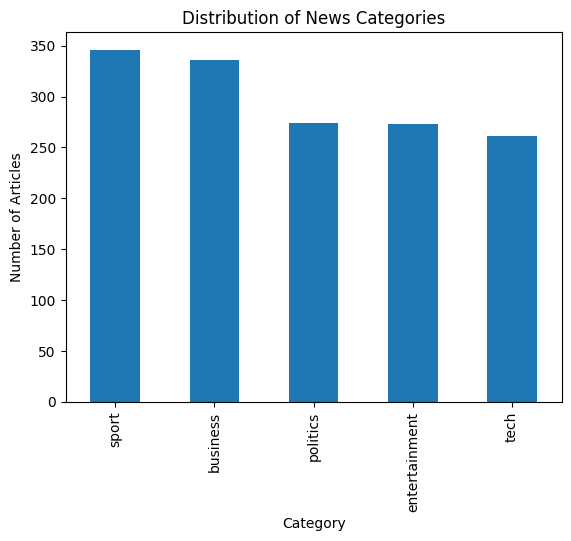

In [17]:
import matplotlib.pyplot as plt

# Plot category distribution
train_df["Category"].value_counts().plot(kind="bar")

plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")

plt.show()

In [18]:
import re
import string
import nltk

from nltk.corpus import stopwords

# Download stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
train_df["Clean_Text"] = train_df["Text"].apply(clean_text)

# Show results
train_df[["Text", "Clean_Text"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Text,Clean_Text
0,worldcom ex-boss launches defence lawyers defe...,worldcom exboss launches defence lawyers defen...
1,german business confidence slides german busin...,german business confidence slides german busin...
2,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens maj...
3,lifestyle governs mobile choice faster bett...,lifestyle governs mobile choice faster better ...
4,enron bosses in $168m payout eighteen former e...,enron bosses payout eighteen former enron dire...


In [19]:
# Tokenize the cleaned text

train_df["Tokens"] = train_df["Clean_Text"].apply(lambda x: x.split())

# Display the first tokenized article
train_df[["Clean_Text", "Tokens"]].head()

,Clean_Text,Tokens
0,worldcom exboss launches defence lawyers defen...,"[worldcom, exboss, launches, defence, lawyers,..."
1,german business confidence slides german busin...,"[german, business, confidence, slides, german,..."
2,bbc poll indicates economic gloom citizens maj...,"[bbc, poll, indicates, economic, gloom, citize..."
3,lifestyle governs mobile choice faster better ...,"[lifestyle, governs, mobile, choice, faster, b..."
4,enron bosses payout eighteen former enron dire...,"[enron, bosses, payout, eighteen, former, enro..."


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Transform the cleaned text
X = tfidf.fit_transform(train_df["Clean_Text"])

# Labels
y = train_df["Category"]

print("TF-IDF Matrix Shape:", X.shape)
print("Number of Labels:", len(y))

TF-IDF Matrix Shape: (1490, 5000)
Number of Labels: 1490


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9664429530201343

Classification Report:
               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       0.98      0.98      0.98        46
     politics       0.96      0.95      0.95        56
        sport       0.98      1.00      0.99        63
         tech       0.98      0.93      0.96        58

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



In [22]:
# Test with a new article

new_article = """
Apple has announced a new artificial intelligence system for iPhones.
The company revealed several new features powered by machine learning
during its annual developer conference.
"""

# Clean the text
clean_article = clean_text(new_article)

# Convert to TF-IDF
article_vector = tfidf.transform([clean_article])

# Predict
prediction = model.predict(article_vector)

print("Predicted Category:", prediction[0])

Predicted Category: tech


In [23]:
import spacy

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Test NER on one article
sample_text = train_df.loc[0, "Text"]
doc = nlp(sample_text)

print("Named Entities Found:")
for ent in doc.ents[:20]:
    print(ent.text, "->", ent.label_)

Named Entities Found:
first -> ORDINAL
cynthia cooper -> PERSON
us -> GPE
2002 -> DATE
5.7bn -> MONEY
new york -> GPE
wednesday -> DATE
arthur andersen -> PERSON
early 2001 and -> DATE
2002 -> DATE
scott sullivan -> PERSON
sullivan -> PERSON
worldcom s accounting -> ORG
2001 -> DATE
85 years -> DATE
2004 -> DATE
mci -> ORG
last week -> DATE
mci -> ORG
6.75bn -> MONEY


In [24]:
# Part-of-Speech (POS) Tagging

doc = nlp(train_df.loc[0, "Text"])

print("First 30 tokens with POS tags:\n")

for token in doc[:30]:
    print(f"{token.text:<15} {token.pos_:<10} {token.tag_}")

First 30 tokens with POS tags:

worldcom        PROPN      NNP
ex              PROPN      NNP
-               NOUN       NN
boss            NOUN       NN
launches        VERB       VBZ
defence         NOUN       NN
lawyers         NOUN       NNS
defending       VERB       VBG
former          ADJ        JJ
worldcom        PROPN      NNP
chief           PROPN      NNP
bernie          PROPN      NNP
ebbers          NOUN       NNS
against         ADP        IN
a               DET        DT
battery         NOUN       NN
of              ADP        IN
fraud           NOUN       NN
charges         NOUN       NNS
have            AUX        VBP
called          VERB       VBN
a               DET        DT
company         NOUN       NN
whistleblower   ADJ        JJR
as              ADP        IN
their           PRON       PRP$
first           ADJ        JJ
witness         NOUN       NN
.               PUNCT      .
                SPACE      _SP


In [25]:
# Syntax Parsing (Dependency Parsing)

doc = nlp(train_df.loc[0, "Text"])

print("Dependency Parsing:\n")

for token in doc[:30]:
    print(f"{token.text:<15} --> {token.dep_:<15} Head: {token.head.text}")

Dependency Parsing:

worldcom        --> compound        Head: launches
ex              --> compound        Head: launches
-               --> nsubj           Head: launches
boss            --> nsubj           Head: launches
launches        --> ROOT            Head: launches
defence         --> compound        Head: lawyers
lawyers         --> dobj            Head: launches
defending       --> acl             Head: lawyers
former          --> amod            Head: ebbers
worldcom        --> compound        Head: ebbers
chief           --> compound        Head: ebbers
bernie          --> compound        Head: ebbers
ebbers          --> dobj            Head: defending
against         --> prep            Head: defending
a               --> det             Head: battery
battery         --> pobj            Head: against
of              --> prep            Head: battery
fraud           --> compound        Head: charges
charges         --> pobj            Head: of
have            --> aux     

In [26]:
from textblob import TextBlob

# Analyze sentiment
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Apply sentiment analysis
train_df["Sentiment"] = train_df["Text"].apply(get_sentiment)

# Show first results
train_df[["Category", "Sentiment"]].head()

,Category,Sentiment
0,business,0.023320
1,business,0.077917
2,business,0.077754
3,tech,0.156109
4,business,0.009685


Category
business         0.060208
entertainment    0.149388
politics         0.070835
sport            0.109242
tech             0.101660
Name: Sentiment, dtype: float64


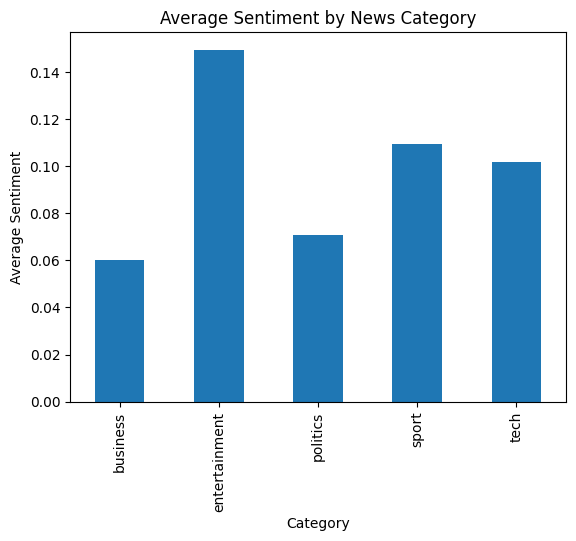

In [27]:
import matplotlib.pyplot as plt

# Average sentiment by category
sentiment_by_category = train_df.groupby("Category")["Sentiment"].mean()

print(sentiment_by_category)

sentiment_by_category.plot(kind="bar")

plt.title("Average Sentiment by News Category")
plt.xlabel("Category")
plt.ylabel("Average Sentiment")
plt.show()

# NewsBot Intelligence System

## ITAI 2373 - Midterm Project

### Student
David Massiala

### Project Overview

This project presents a NewsBot Intelligence System developed using Natural Language Processing (NLP). The system automatically processes news articles, cleans the text, extracts useful information, analyzes sentiment, identifies named entities, and classifies articles into different news categories.

The project was developed in Google Colab using Python, scikit-learn, spaCy, NLTK, pandas, and matplotlib.

# Conclusion

The NewsBot Intelligence System successfully demonstrates a complete NLP pipeline.

The project includes:

- Text preprocessing
- Tokenization
- TF-IDF feature extraction
- POS tagging
- Dependency parsing
- Named Entity Recognition
- Sentiment Analysis
- Multi-class Text Classification

The Logistic Regression classifier achieved an accuracy of approximately 96%, showing that NLP techniques can effectively classify news articles and extract meaningful information for business intelligence applications.
